# Kinetic Energy Mean-Transient Decomposition

This recipe decomposing kinetic energy into time-mean and transient components.

### Background

For a hydrostatic ocean model, like MOM5, the relevant kinetic energy per unit mass is 

$$ {\rm KE} = \frac{1}{2} (u^2 + v^2).$$

The vertical velocity component, $w$, does not appear in the mechanical energy budget. It is very much subdominant. But more fundamentally, it simply does not appear in the mechanical energy buget for a hydrostatic ocean. 

For a non-steady fluid, we can define the time-averaged kinetic energy as the __total kinetic energy__, TKE

$$ {\rm TKE} = \left< {\rm KE} \right > {\stackrel{\rm{def}}{=}} \frac{1}{T} \int_0^T \frac{1}{2} \left( u^2 + v^2 \right)\,\mathrm{d}t.$$

It is useful to decompose the velocity into time-mean and time-varying components, e.g.,

$$ u = \bar{u} + u'.$$

The __mean kinetic energy__ is the energy associated with the mean flow

$$ {\rm MKE} = \frac{1}{2} \left( \bar{u}^2 + \bar{v}^2 \right) $$

The kinetic energy of the time varying component is the __eddy kinetic energy__, EKE. This quantity can be obtained by 
substracting the velocity means and calculating the kinetic energy of the 
perturbation velocity quantities.

$$ {\rm EKE} =  \overline{ \frac{1}{2} \left[ \left(u - \overline{u}\right)^2 + \left(v - \overline{v}\right)^2 \right] } $$
                                 
MKE and EKE partition the total kinetic energy

$${\rm TKE} = {\rm MKE} + {\rm EKE}.$$

---

### Requirements

This recipe uses MOM5. For adaptation to MOM6, please take into account the following equivalent diagnostics:

| MOM5 diagnostic (x-coord,y-coord) | MOM6 diagnostic (x-coord,y-coord) | 
|-----|------|
| `u(xu_ocean,yu_ocean)` | `uo(xq,yh)` | 
| `v(xu_ocean,yu_ocean)` | `vo(xq,yh)` | 
| `dzt(xt_ocean,yt_ocean)` | `thickcello(xh,yh)`, or if not available can be calculated by `volcello / areacello` | 

Note that in MOM5 velocities are calculated in the (north-east) corner of the cells, where the dimension names are `xu_ocean` and `yu_ocean`. In MOM6, velocities are calculated in the eastern face of the cell for `uo` and northern face of the cell for `vo`. To adapt this recipe, you would need to do some interpolations using `xgcm`. For example, an option would be to interpolate first `uo` and `vo` to be in the (north-east) corner, where the dimensions are (`xq`, `yq`).

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as feature
import cmocean as cm
import intake
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from dask.distributed import Client

In [2]:
client = Client(threads_per_worker = 1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33125 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:33125/status,
Dashboard: http://127.0.0.1:33125/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39309,Workers: 0
Dashboard: http://127.0.0.1:33125/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44767,Total threads: 1
Dashboard: http://127.0.0.1:36455/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:34863,


Open ACCESS-NRI default catalog

In [3]:
catalog = intake.cat.access_nri

Choose an experiment which has daily velocities saved for the Southern Ocean (you can also perhaps choose an experiment with 5 day velocities).

In [4]:
expt = '01deg_jra55v13_ryf9091'

For this recipe we will just load 1 month of daily velocities, but if you want to do the decomposition with output longer than, e.g., 1 year then we suggest you either convert this to a `.py` script and submit through the queue via `qsub` or figure a way to scale `dask` up to larger `ncpus`.

In [5]:
dates = '2100-12.*'

In [6]:
def select_region(ds):
    ds = ds.sel(yu_ocean=slice(None, -50))
    return ds

darray = catalog[expt].search(
                variable = 'u',
                frequency = '1day',
                start_date=dates).to_dask(preprocess=select_region)
u = darray['u']

darray = catalog[expt].search(
                variable = 'v',
                frequency = '1day',
                start_date=dates).to_dask(preprocess=select_region)
v = darray['v']

Make model's land mask and define a plotting function:

In [7]:
ht = catalog[expt].search(variable = 'ht',
                          frequency = 'fx').to_dask()
land_mask = xr.where(np.isnan(ht['ht']), 1, np.nan)
land_mask = land_mask.rename('land_mask').sel(yt_ocean = slice(None, -49))

land_50m = feature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor='black',
                                        facecolor='gray',
                                        linewidth=0.2)
def circumpolar_map():
    fig = plt.figure(figsize = (12, 8))
    ax = plt.axes(projection = ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -80, -50], crs = ccrs.PlateCarree())
    ax.set_facecolor('lightgrey')
    # Map the plot boundaries to a circle
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)
    land_mask.plot.contourf(ax = ax, colors = 'lightgrey', add_colorbar = False, 
                            zorder = 2, transform = ccrs.PlateCarree())
    return fig, ax

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


The kinetic energy is 

$$ {\rm KE} = \frac{1}{2} (u^2 + v^2).$$

We construct the following expression:

In [8]:
KE = 0.5*(u**2 + v**2)

You may notice that this line runs instantly. The calculation is not (yet) computed. Rather, `xarray` needs to broadcast the squares of the velocity fields together to determine the final shape of KE. 

This is too large to store locally.  We need to reduce the data in some way.  

The mean kinetic energy is calculated by this function, which returns the depth integrated KE:

$$ \int_{z_0}^{z} \mathrm{KE}\,\mathrm{d}z.$$

Let's load the cell thickness ($dz$), and interpolate to the u-grid. Cell thickness varies with time with stretching and squashing of the water column, but experiments don't usually save it at a daily time step. So we will use the monthly average:

In [9]:
dzt = catalog[expt].search(
            variable='dzt',
            frequency='1mon', 
            start_date='2100.*').to_dask()
dzt = dzt.sel(time='2100-12-16')
# Interpolate to the u-grid (note that some experiments might have dzu available)
dzu = dzt['dzt'].rename({'xt_ocean':'xu_ocean', 'yt_ocean':'yu_ocean'}).interp(xu_ocean = u['xu_ocean'], yu_ocean = u['yu_ocean']).squeeze()

In [10]:
KE_dz = KE*dzu

In [11]:
TKE = KE_dz.mean('time').sum('st_ocean')

In [12]:
%%time
TKE = TKE.load()

CPU times: user 44.2 s, sys: 27 s, total: 1min 11s
Wall time: 1min 12s


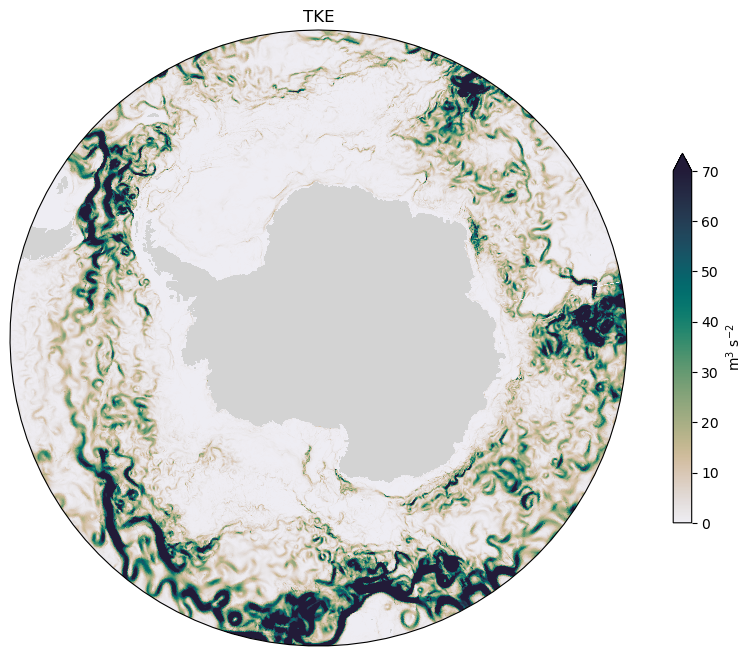

In [13]:
fig, axs = circumpolar_map()
TKE.plot(ax = axs, vmax = 70, cmap = cm.cm.rain, transform = ccrs.PlateCarree(),
         cbar_kwargs = {'label':'m$^3$ s$^{-2}$', 'shrink':0.6});
axs.set_title('TKE');

Snapshot plot of depth-integrated KE for a random time step:

In [14]:
KE_snapshot = KE_dz.isel(time = 0).sum('st_ocean')
KE_snapshot = KE_snapshot.load()

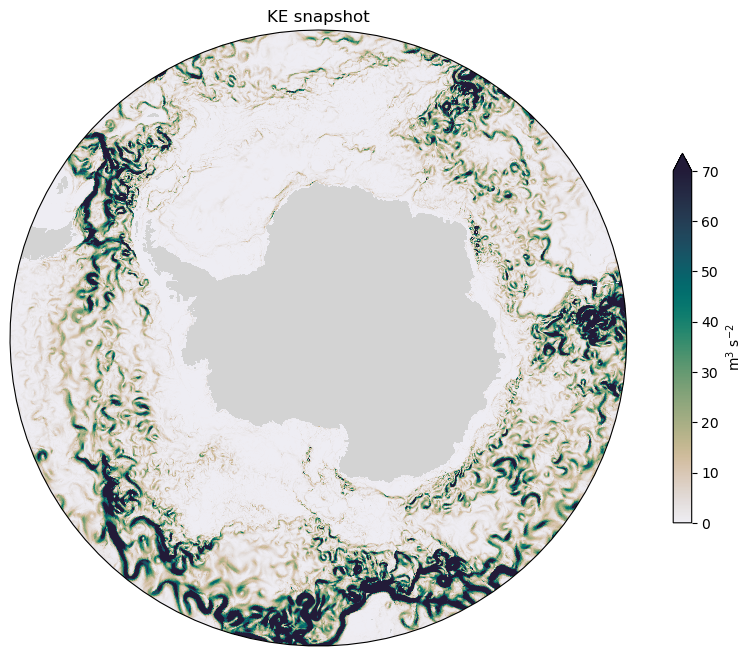

In [15]:
fig, axs = circumpolar_map()
KE_snapshot.plot(ax = axs, vmax = 70, cmap = cm.cm.rain, transform = ccrs.PlateCarree(),
                 cbar_kwargs = {'label':'m$^3$ s$^{-2}$', 'shrink':0.6});
axs.set_title('KE snapshot');

### Mean Kinetic Energy

For the mean kinetic energy, we need to average the velocities over time.

$$ {\rm MKE} = \frac{1}{2} \left( \bar{u}^2 + \bar{v}^2 \right). $$

In [16]:
u_mean = u.mean('time')
v_mean = v.mean('time')

In [17]:
MKE = (0.5*(u_mean**2 + v_mean**2)*dzu).sum('st_ocean')

In [18]:
MKE = MKE.load()

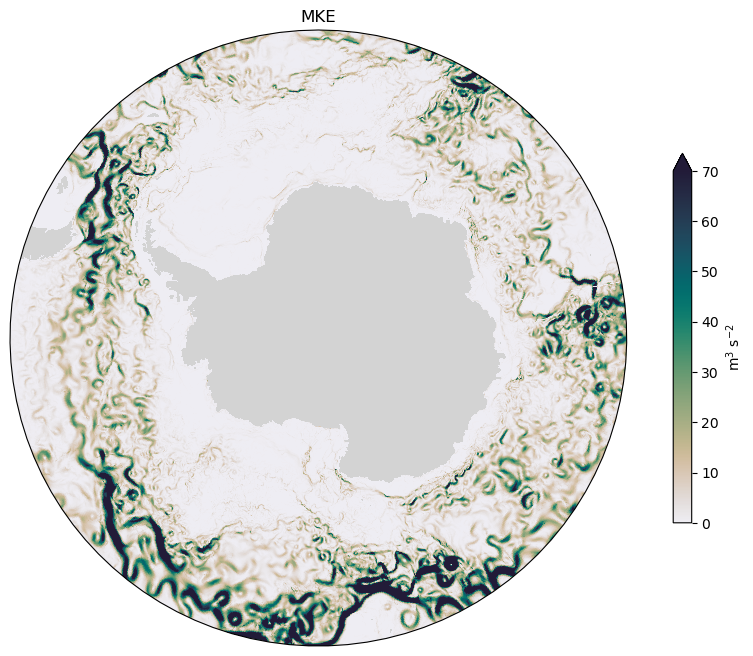

In [19]:
fig, axs = circumpolar_map()
MKE.plot(ax = axs, vmax = 70, cmap = cm.cm.rain, transform = ccrs.PlateCarree(),
         cbar_kwargs = {'label':'m$^3$ s$^{-2}$', 'shrink':0.6});
axs.set_title('MKE');

### Eddy Kinetic Energy

We calculate the transient component of the velocity field and then compute the EKE:


$$ {\rm EKE} =  \overline{ \frac{1}{2} \left[ \left(u - \overline{u}\right)^2 + \left(v - \overline{v}\right)^2 \right] }. $$

In [20]:
u_transient = u - u_mean
v_transient = v - v_mean

In [21]:
EKE = (0.5*(u_transient**2 + v_transient**2)*dzu).sum('st_ocean').mean('time')

In [22]:
EKE = EKE.load()

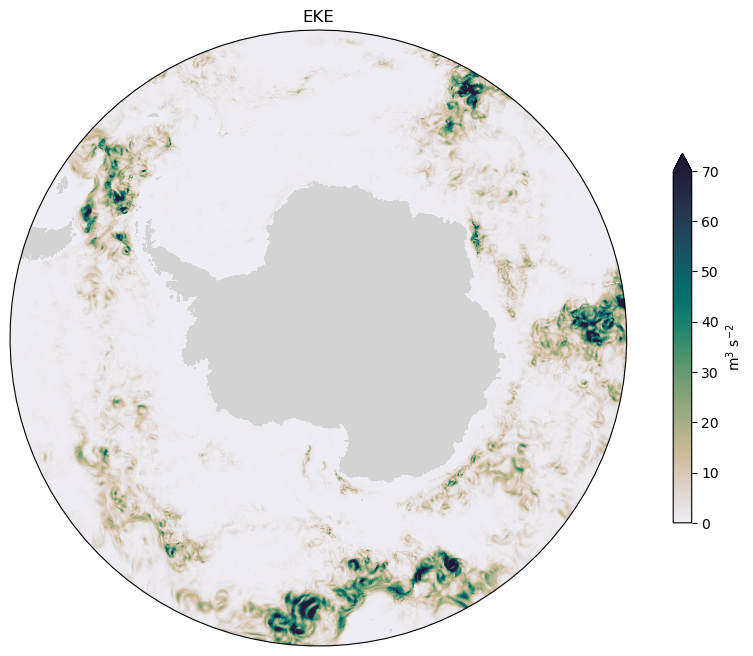

In [23]:
fig, axs = circumpolar_map()
EKE.plot(ax = axs, vmax = 70, cmap = cm.cm.rain, transform = ccrs.PlateCarree(),
         cbar_kwargs = {'label':'m$^3$ s$^{-2}$', 'shrink':0.6});
axs.set_title('EKE');

In [24]:
client.close()